# Customer Churn Prediction using Logistic Regression

## 1. Import Libraries

In [361]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [362]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

## 2. Load Dataset

In [363]:
df = pd.read_csv("../Dataset/WA_Fn-UseC_-Telco-Customer-Churn.csv")

## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is performed to understand the structure of the dataset, identify missing values, examine data types, and gain initial insights before preprocessing and model building.

In [364]:
# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [365]:
# Display last 5 rows
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [366]:
# Dataset dimensions
df.shape

(7043, 21)

In [367]:
# Column names
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [368]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


**Observation:**

- The dataset contains 7043 entries and 21 columns.
- Most features are categorical (`object` type).
- `TotalCharges` is stored as an object instead of a numerical type and will need to be converted during preprocessing.

In [369]:
# Summary statistics
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [370]:
# Missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Observation:**

The dataset does not contain explicit missing values. However, the `TotalCharges` column contains blank strings, which will be handled during the preprocessing stage.

In [371]:
# Identify numerical and categorical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:")
print(numerical_features)

print("\nCategorical Features:")
print(categorical_features)

Numerical Features:
Index(['SeniorCitizen', 'tenure', 'MonthlyCharges'], dtype='object')

Categorical Features:
Index(['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges',
       'Churn'],
      dtype='object')


In [372]:
# Distribution of the target variable
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [373]:
# Percentage distribution of the target variable
(df['Churn'].value_counts(normalize=True) * 100).round(2)

Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

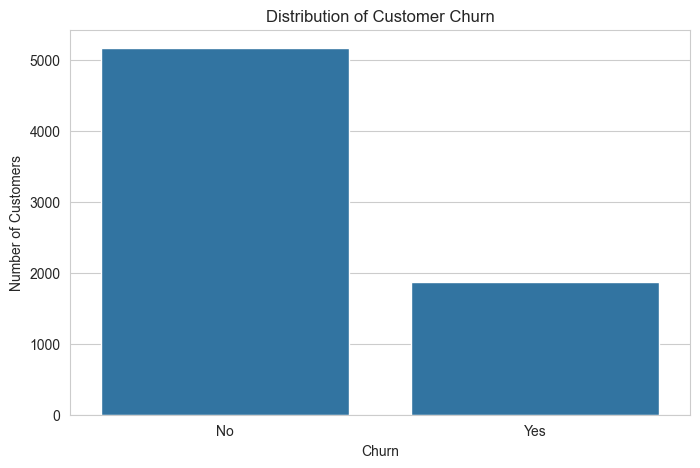

In [374]:
# Visualize the target variable
sns.countplot(x='Churn', data=df)

plt.title("Distribution of Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.savefig("../Images/churn_distribution.png",
    dpi=300,
    bbox_inches='tight')

plt.show()

**Observation:**

- The dataset is imbalanced, with a significantly larger number of customers who did not churn (`No`) compared to those who churned (`Yes`).
- Approximately 73% of customers stayed with the company, while about 27% left.
- Due to this class imbalance, evaluation metrics such as Precision, Recall, F1-score, and ROC-AUC should be considered in addition to accuracy.

#### Numerical Feature Distribution

Histograms are used to understand the distribution of numerical variables and identify any skewness or unusual patterns in the dataset.

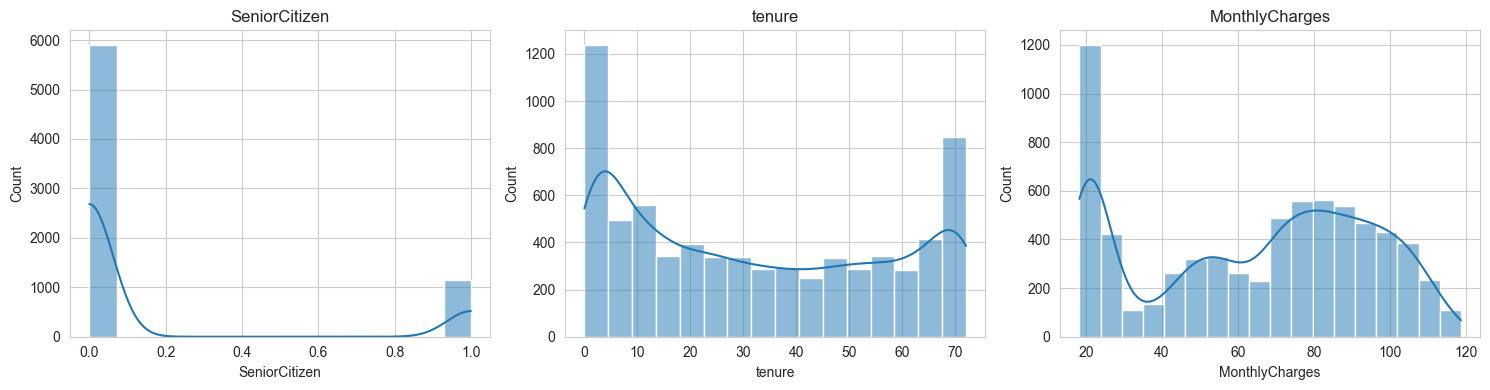

In [375]:
# Histograms for numerical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical_features):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.savefig("../Images/numerical_histograms.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

**Observation:**

- The `SeniorCitizen` feature is binary, with the majority of customers belonging to the non-senior citizen category (0).
- The `tenure` distribution indicates that many customers are either relatively new (low tenure) or have remained with the company for a long period (around 70 months), with fewer customers in the middle tenure range.
- The `MonthlyCharges` distribution is not normally distributed. A large number of customers have lower monthly charges, while another concentration of customers falls between approximately 70 and 100 units, indicating the presence of different subscription plans.

#### Boxplot Analysis

Boxplots are used to visualize the spread of numerical features and identify potential outliers.

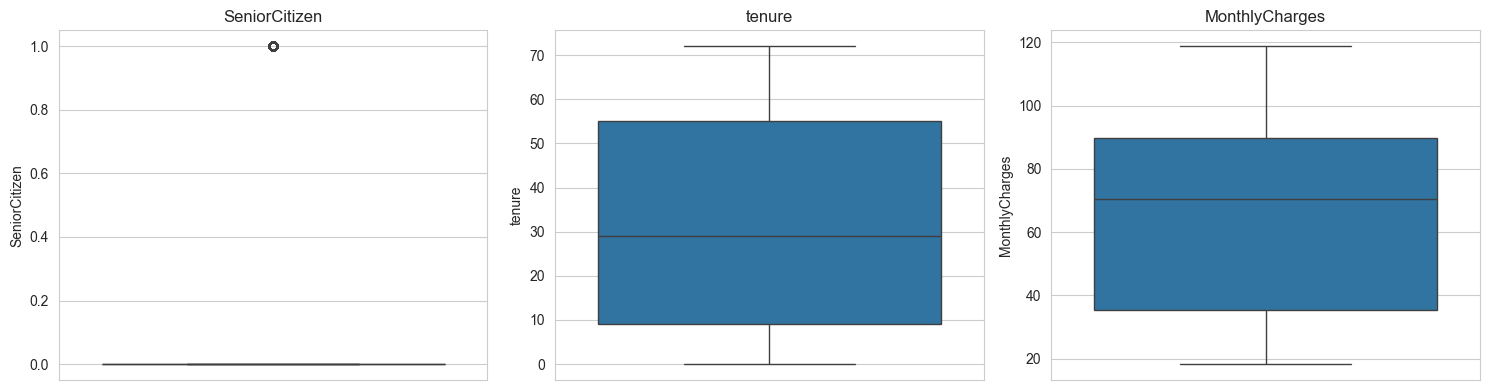

In [376]:
# Boxplots for numerical features
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, col in enumerate(numerical_features):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()

plt.savefig("../Images/numerical_boxplots.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

**Observation:**

- The `SeniorCitizen` feature is binary and therefore appears to have values concentrated at 0 and 1, making the point at 1 appear as an outlier in the boxplot even though it represents a valid category.
- The `tenure` feature shows a wide distribution without any significant outliers.
- The `MonthlyCharges` feature also does not exhibit any noticeable outliers, indicating that the values fall within an expected range.

#### Correlation Analysis

A correlation heatmap helps visualize the relationship among numerical variables and identifies features that may be strongly associated with one another.

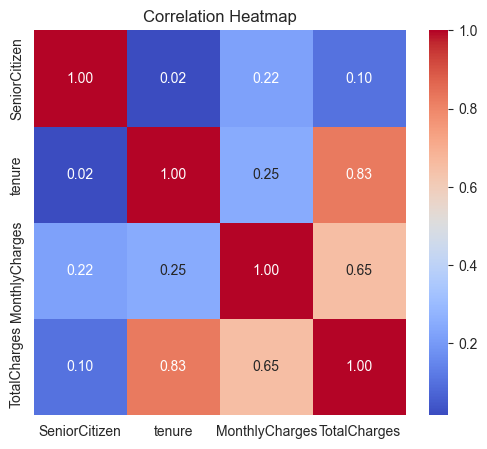

In [377]:
# Convert TotalCharges to numeric for correlation analysis
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Correlation heatmap
plt.figure(figsize=(6,5))

corr = df[['SeniorCitizen',
           'tenure',
           'MonthlyCharges',
           'TotalCharges']].corr()

sns.heatmap(corr,
            annot=True,
            cmap='coolwarm',
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.savefig("../Images/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight")

plt.show()

**Observation:**

- `tenure` and `TotalCharges` have a strong positive correlation (0.83), indicating that customers who stay longer tend to accumulate higher total charges.
- `MonthlyCharges` has a moderate positive correlation with `TotalCharges` (0.65), suggesting that higher monthly plans contribute to greater overall spending.
- `MonthlyCharges` and `tenure` exhibit a weak positive correlation (0.25), indicating only a slight relationship between subscription duration and monthly billing.
- `SeniorCitizen` has very weak correlations with the other numerical features, implying that senior citizen status has little linear relationship with billing or tenure.

## 4. Data Preprocessing

#### Data Cleaning

Before building the machine learning model, the dataset must be cleaned by handling incorrect data types, missing values, and unnecessary features.

In [378]:
# Convert TotalCharges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check data type
df['TotalCharges'].dtype

# Check missing values after conversion
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

**Observation:**

- After converting `TotalCharges` to a numeric data type, 11 missing values are identified.
- These missing values originated from blank entries in the original dataset and must be handled before model training.

In [379]:
# Remove rows with missing values
df.dropna(inplace=True)

# Verify missing values
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

**Observation:**

- The missing values have been successfully removed.
- Since only 11 records were affected, removing them has a negligible impact on the overall dataset.

In [380]:
# Remove customerID column
df.drop('customerID', axis=1, inplace=True)

# Display first five rows
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


**Observation:**

- The `customerID` column has been removed because it is a unique identifier and does not provide useful information for predicting customer churn.

#### Encoding Categorical Variables

Machine learning algorithms require numerical input. Therefore, categorical features are converted into numerical values using appropriate encoding techniques.

In [381]:
# Encode target variable
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

# Verify encoding
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

**Observation:**

- The target variable has been encoded successfully, where `No` is represented as 0 and `Yes` as 1.
- This numerical representation is suitable for Logistic Regression.

In [382]:
# One-Hot Encode categorical features
df = pd.get_dummies(df, drop_first=True)

# Display first five rows
df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


In [383]:
# Dataset shape after encoding
df.shape

(7032, 31)

In [384]:
# Display column names
df.columns

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn',
       'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes',
       'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

**Observation:**

- All categorical features have been successfully converted into numerical format using One-Hot Encoding.
- The number of features has increased because each categorical variable has been transformed into one or more binary columns.
- The dataset is now fully numerical and ready for machine learning.

In [385]:
# Separate input features and target variable
X = df.drop('Churn', axis=1)
y = df['Churn']

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (7032, 30)
Target Shape: (7032,)


**Observation:**

- The dataset has been divided into input features (`X`) and the target variable (`y`).
- This separation is required before splitting the dataset into training and testing sets.

In [386]:
# Split the dataset into training and testing sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Set:", X_train.shape)
print("Testing Set:", X_test.shape)

Training Set: (5625, 30)
Testing Set: (1407, 30)


**Observation:**

- The dataset has been split into 80% training data and 20% testing data.
- Stratified sampling has been used to preserve the original class distribution in both training and testing datasets.

In [387]:
# Standardize the features
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


**Observation:**

- Feature scaling has been applied using `StandardScaler`, which standardizes each feature to have a mean of 0 and a standard deviation of 1.
- The scaler is fitted only on the training data and then applied to the testing data to prevent data leakage.

## 5. Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for binary classification problems. In this project, it is used to predict whether a customer is likely to churn based on the available features.

### Hyperparameter Documentation & Justification

The Logistic Regression model is trained using standard hyperparameters in `scikit-learn`. Below is a documentation and justification of these parameters:

1. **Regularization Penalty (`penalty='l2'`):**
   - **Description:** Specifies the norm used in the penalization. L2 regularization (Ridge) adds a penalty term proportional to the square of the magnitude of coefficients.
   - **Justification:** Since the dataset contains 30 features after One-Hot Encoding, some features might exhibit multicollinearity (e.g., streaming services, contract terms). L2 regularization helps to shrink the coefficients of correlated features, reducing variance and preventing overfitting without removing variables entirely.

2. **Regularization Strength (`C=1.0`):**
   - **Description:** Inverse of regularization strength ($C = 1/\lambda$). Smaller values specify stronger regularization.
   - **Justification:** The default value of `C=1.0` provides a balanced trade-off between bias and variance. It regularizes the model sufficiently to generalize well on the testing set (achieving an ROC-AUC of 0.8357) while maintaining enough model complexity to capture the underlying relationships in the training data.

3. **Optimization Solver (`solver='lbfgs'`):**
   - **Description:** Algorithm used for optimization. `lbfgs` stands for Limited-memory Broyden–Fletcher–Goldfarb–Shanno.
   - **Justification:** The `lbfgs` solver is a quasi-Newton optimization method that is memory-efficient and converges rapidly for small-to-medium datasets (like this dataset of 7,032 records). It natively supports L2 regularization and handles multi-class and binary problems robustly.

4. **Random State (`random_state=42`):**
   - **Description:** Seed used by the random number generator.
   - **Justification:** Ensures reproducibility of the optimization solver's internal shuffling, guaranteeing that the model coefficients and performance metrics remain identical across multiple runs.

In [388]:
# Create Logistic Regression model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


**Observation:**

- The Logistic Regression model has been successfully trained using the training dataset.
- The trained model will now be used to predict customer churn on the testing dataset.

In [389]:
# Predict on test data
y_pred = model.predict(X_test)

# Display first 10 predictions
print("Predicted Values:")
print(y_pred[:10])

Predicted Values:
[0 1 0 0 0 0 0 0 1 0]


In [390]:
# Probability of customer churning
y_pred_prob = model.predict_proba(X_test)[:, 1]

print(y_pred_prob[:10])

[0.01711495 0.59613179 0.00476432 0.20004408 0.10022205 0.4700293
 0.02661132 0.16414898 0.68614136 0.01518016]


**Observation:**

- The model has generated predictions for the testing dataset.
- In addition to class predictions, probability scores have also been computed, which indicate the likelihood of each customer churning.

## 6. Model Evaluation

The performance of the Logistic Regression model is evaluated using various classification metrics to assess its ability to accurately predict customer churn.

In [391]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

In [392]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8038


**Observation:**

- The Logistic Regression model achieved an accuracy of **80.38%** on the testing dataset.
- This indicates that the model correctly classified approximately 8 out of every 10 customers.
- However, since the dataset is imbalanced, additional evaluation metrics are considered to provide a more comprehensive assessment of the model's performance.

In [393]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[916 117]
 [159 215]]


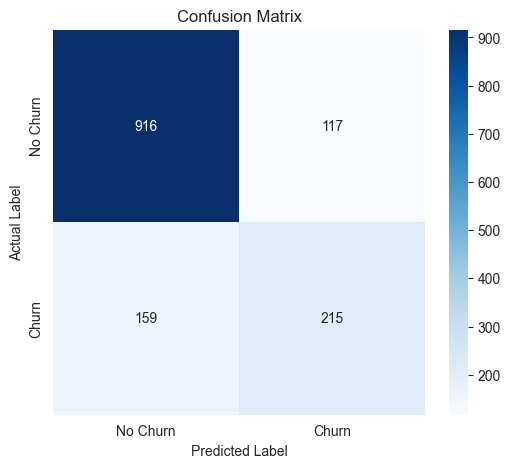

In [394]:
plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.savefig("../Images/confusion_matrix.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation:**

- The model correctly classified **916** customers who did not churn (True Negatives) and **215** customers who churned (True Positives).
- It incorrectly predicted **117** non-churning customers as churners (False Positives) and failed to identify **159** actual churning customers (False Negatives).
- The model performs well in identifying customers who do not churn but is comparatively less effective in detecting customers who are likely to churn.

In [395]:
# Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



**Observation:**

- The model achieved a higher Precision (0.85), Recall (0.89), and F1-score (0.87) for the non-churn class (`0`), indicating strong performance in identifying customers who remain with the company.
- For the churn class (`1`), the Precision is **0.65**, Recall is **0.57**, and F1-score is **0.61**, showing that predicting customer churn is more challenging.
- The weighted average F1-score of **0.80** indicates that the model performs reasonably well overall despite the class imbalance.

In [396]:
# Precision
precision = precision_score(y_test, y_pred)

# Recall
recall = recall_score(y_test, y_pred)

# F1 Score
f1 = f1_score(y_test, y_pred)

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

Precision : 0.6476
Recall    : 0.5749
F1 Score  : 0.6091
ROC-AUC   : 0.8357


**Observation:**

- The model achieved a Precision of **0.6476**, indicating that approximately 65% of the customers predicted to churn actually churned.
- The Recall of **0.5749** shows that the model successfully identified about 57% of the actual churning customers.
- The F1-score of **0.6091** reflects a balanced trade-off between Precision and Recall.
- The ROC-AUC score of **0.8357** indicates good discriminative ability, demonstrating that the model can effectively distinguish between customers who churn and those who do not.

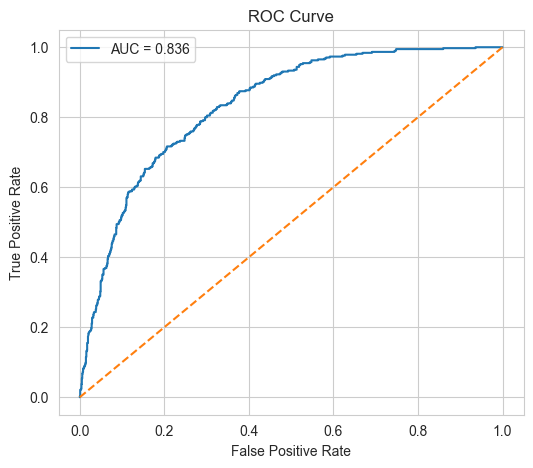

In [397]:
# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.savefig("../Images/roc_curve.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation:**

- The ROC curve lies well above the diagonal reference line, indicating that the Logistic Regression model performs significantly better than random guessing.
- The Area Under the Curve (AUC) of **0.836** demonstrates good classification performance and the model's ability to distinguish between churning and non-churning customers.

## 7. Model Interpretation

The Logistic Regression model assigns a coefficient to each feature. A positive coefficient indicates that the feature increases the likelihood of customer churn, while a negative coefficient indicates that the feature decreases the likelihood of customer churn.

In [398]:
# Extract model coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coefficients.head()

,Feature,Coefficient
0,SeniorCitizen,0.070792
1,tenure,-1.347613
2,MonthlyCharges,-0.851551
3,TotalCharges,0.639028
4,gender_Male,-0.011693


In [399]:
# Sort coefficients
coefficients = coefficients.sort_values(by='Coefficient', ascending=False)

coefficients.reset_index(drop=True)

,Feature,Coefficient
0,InternetService_Fiber optic,0.727745
1,TotalCharges,0.639028
2,StreamingTV_Yes,0.249702
3,StreamingMovies_Yes,0.236368
4,MultipleLines_Yes,0.214359
5,PaymentMethod_Electronic check,0.181473
6,PaperlessBilling_Yes,0.142663
7,SeniorCitizen,0.070792
8,DeviceProtection_Yes,0.068965
9,PaymentMethod_Mailed check,0.033392


In [400]:
# Top 10 positive coefficients
top_positive = coefficients.head(10).reset_index(drop=True)
top_positive

,Feature,Coefficient
0,InternetService_Fiber optic,0.727745
1,TotalCharges,0.639028
2,StreamingTV_Yes,0.249702
3,StreamingMovies_Yes,0.236368
4,MultipleLines_Yes,0.214359
5,PaymentMethod_Electronic check,0.181473
6,PaperlessBilling_Yes,0.142663
7,SeniorCitizen,0.070792
8,DeviceProtection_Yes,0.068965
9,PaymentMethod_Mailed check,0.033392


In [401]:
# Top 10 negative coefficients
top_negative = coefficients.tail(10).reset_index(drop=True)
top_negative

,Feature,Coefficient
0,TechSupport_No internet service,-0.088138
1,DeviceProtection_No internet service,-0.088138
2,StreamingMovies_No internet service,-0.088138
3,Dependents_Yes,-0.105956
4,TechSupport_Yes,-0.118240
5,OnlineSecurity_Yes,-0.136804
6,Contract_One year,-0.310898
7,Contract_Two year,-0.602591
8,MonthlyCharges,-0.851551
9,tenure,-1.347613


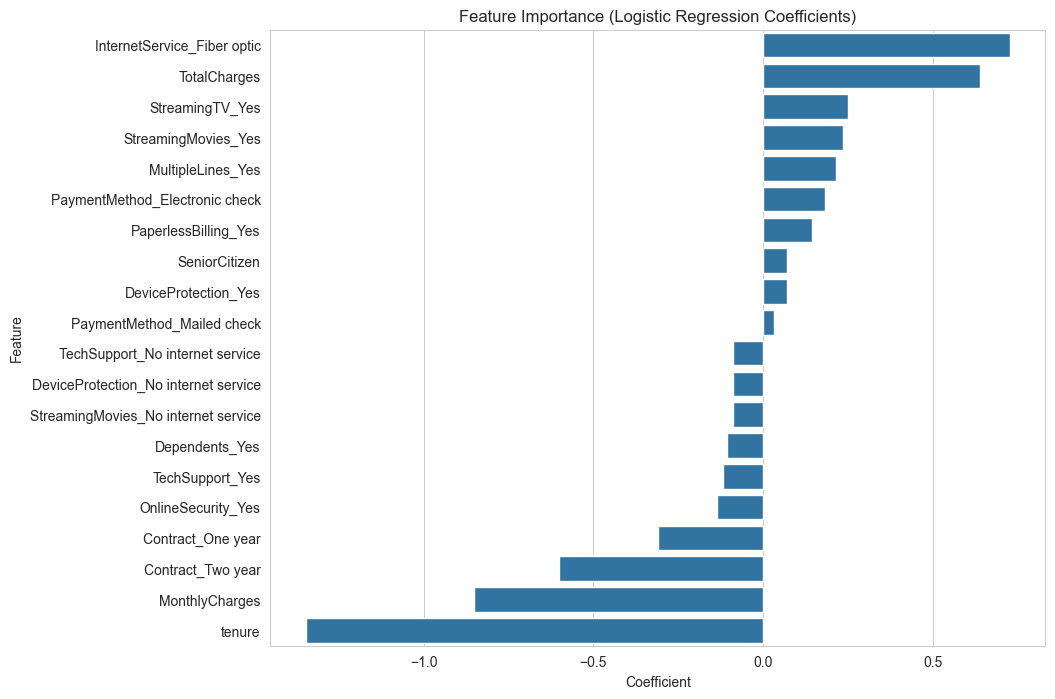

In [402]:
# Top 10 most influential features
top_features = pd.concat([
    coefficients.head(10),
    coefficients.tail(10)
])

plt.figure(figsize=(10,8))

sns.barplot(
    data=top_features,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance (Logistic Regression Coefficients)")

plt.savefig("../Images/feature_importance.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

**Observation:**

- The Logistic Regression coefficients indicate that **InternetService_Fiber optic** has the strongest positive influence on customer churn, followed by features such as **TotalCharges**, **StreamingTV_Yes**, **StreamingMovies_Yes**, **MultipleLines_Yes**, and **PaymentMethod_Electronic check**.
- Features with negative coefficients reduce the likelihood of churn. Among these, **tenure** has the strongest negative influence, indicating that customers who have stayed with the company for a longer period are less likely to churn.
- Long-term contracts (**Contract_One year** and **Contract_Two year**) also significantly reduce churn, suggesting that customers with longer commitments are more likely to remain with the company.
- Additional services such as **OnlineSecurity_Yes** and **TechSupport_Yes** also contribute to lower churn probability, indicating that customers who utilize these services tend to be more loyal.
- Overall, the model suggests that customer tenure, contract type, internet service, payment method, and value-added services are the most influential factors in predicting customer churn.

## 8. Conclusion

This project successfully developed a **Logistic Regression model** to predict customer churn using the **Telco Customer Churn** dataset. The primary objective was to identify customers who are likely to discontinue the company's services based on their demographic information, account details, and subscribed services.

The project began with **Exploratory Data Analysis (EDA)**, which provided valuable insights into the dataset. The analysis revealed that the dataset was moderately imbalanced, with approximately **73% of customers not churning** and **27% churning**. It also highlighted that `TotalCharges` required conversion to a numerical format and contained a small number of missing values. Correlation analysis showed a strong positive relationship between `tenure` and `TotalCharges`, while the remaining numerical features exhibited relatively weak correlations.

During the **data preprocessing** stage, the dataset was cleaned by converting data types, handling missing values, removing the unnecessary `customerID` feature, encoding categorical variables using One-Hot Encoding, and standardizing the features using `StandardScaler`. These preprocessing steps ensured that the data was suitable for training the Logistic Regression model.

The trained Logistic Regression model achieved an **accuracy of 80.38%** and an **ROC-AUC score of 0.8357**, indicating good overall predictive performance. The confusion matrix and classification report showed that the model performed particularly well in identifying customers who were unlikely to churn, while its performance in detecting actual churn cases was comparatively moderate. This behavior is expected due to the class imbalance present in the dataset.

Model interpretation using the learned coefficients provided meaningful business insights. Features such as **Fiber Optic Internet Service**, **Electronic Check payment method**, **Streaming TV**, **Streaming Movies**, and **Multiple Lines** were associated with an increased likelihood of customer churn. In contrast, **long customer tenure**, **one-year and two-year contracts**, **Online Security**, and **Technical Support** were associated with a reduced likelihood of churn. These findings suggest that customer retention can potentially be improved by encouraging long-term contracts, promoting value-added services, and closely monitoring customers with high-risk characteristics.

Overall, this project demonstrates that Logistic Regression is an effective and interpretable baseline model for customer churn prediction. Although the model achieved good performance, there is scope for further improvement by addressing class imbalance through techniques such as SMOTE or class weighting and by exploring more advanced machine learning algorithms such as **Random Forest**, **XGBoost**, or **Gradient Boosting**. Incorporating additional customer behavioral and usage data could further enhance prediction accuracy and support more effective customer retention strategies.

### Model Summary

| Metric | Value |
|---------|-------|
| Algorithm | Logistic Regression |
| Dataset | Telco Customer Churn |
| Records | 7032 |
| Features | 30 |
| Accuracy | 80.38% |
| Precision | 64.76% |
| Recall | 57.49% |
| F1 Score | 60.91% |
| ROC-AUC | 83.57% |

## Key Business Insights

- Customers using Fiber Optic internet services are more likely to churn.
- Customers with longer tenure are less likely to churn.
- One-year and two-year contracts improve customer retention.
- Customers using Online Security and Tech Support services tend to remain with the company.
- Electronic Check payment method is associated with higher churn.